# Problem Statement

In [1]:
# To Determine the creditworthiness of potential borrowers using various attributes to ensure that loans are given to those most likely to repay them.

In [2]:
# Loading important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
# Load the dataset
df = pd.read_csv("logistic_regression.csv")

# Exploratory Data Analysis (EDA)

In [6]:
# a. Observations on Data
print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null 

In [7]:
# Identify numeric vs categorical attributes
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']
Categorical Columns: ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'earliest_cr_line', 'initial_list_status', 'application_type', 'address']


In [8]:
# Missing value detection
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64


In [9]:
# Convert categorical columns to 'category' type
for col in categorical_cols:
    df[col] = df[col].astype('category')

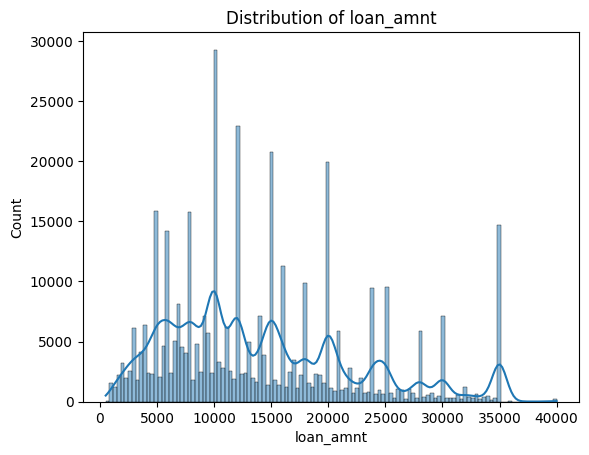

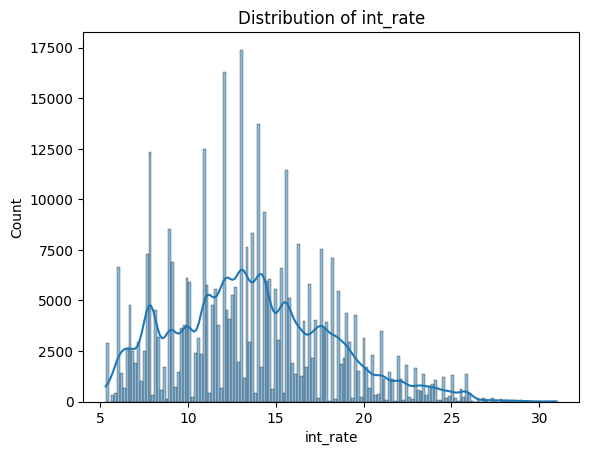

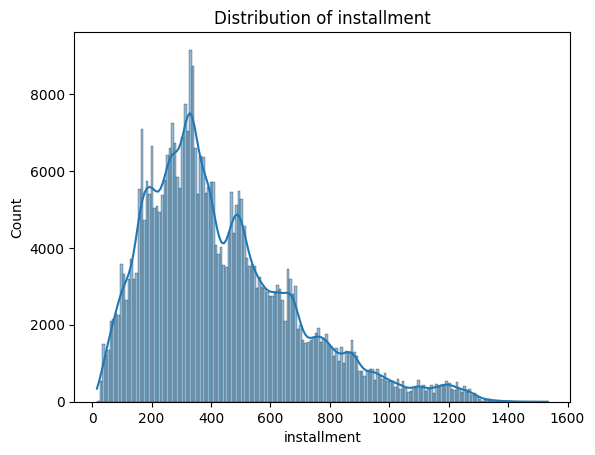

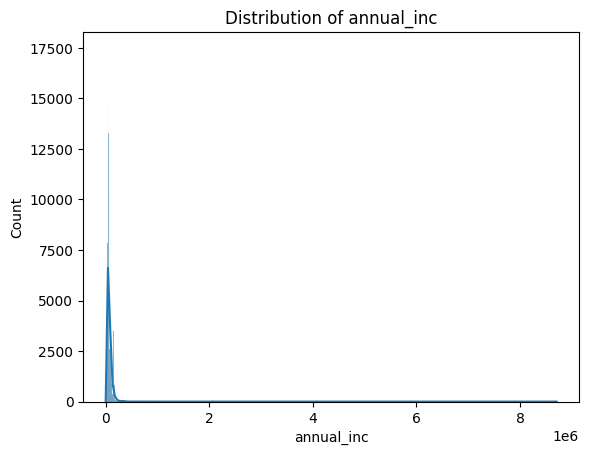

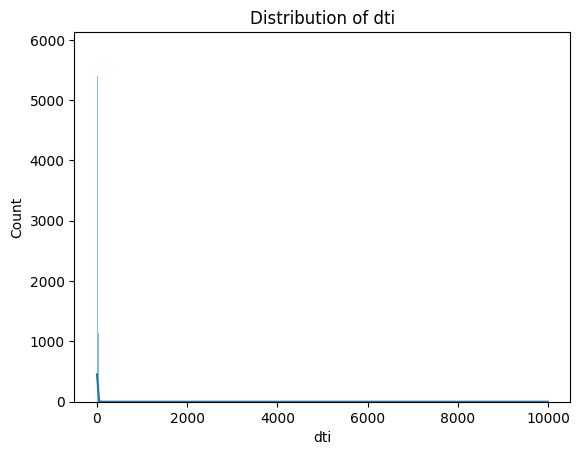

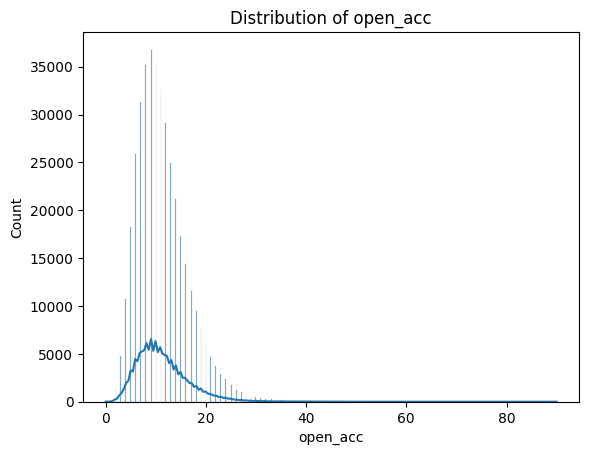

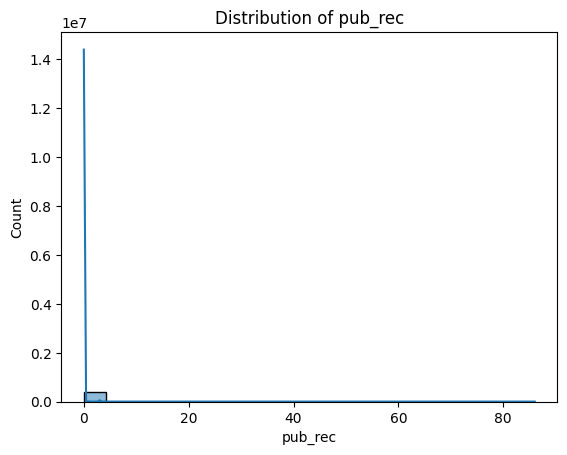

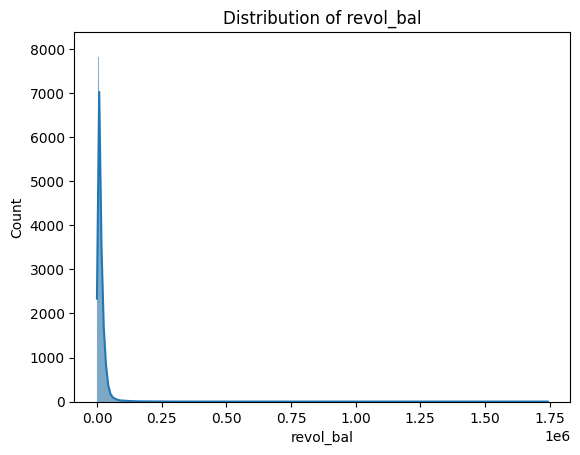

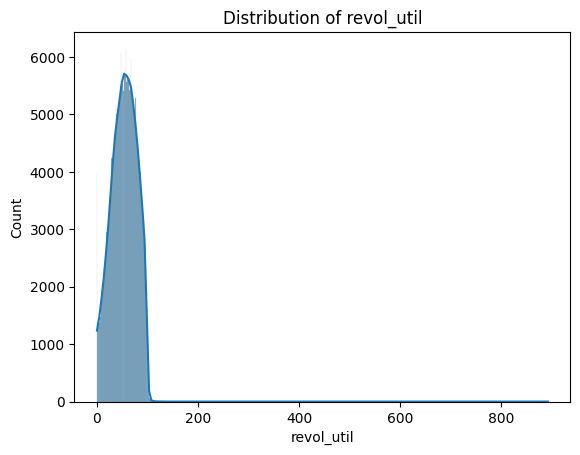

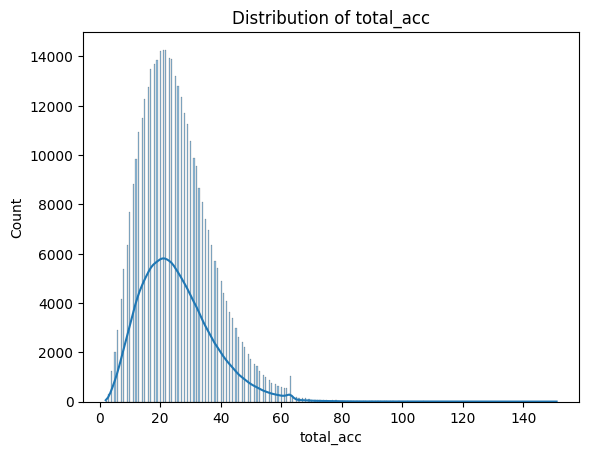

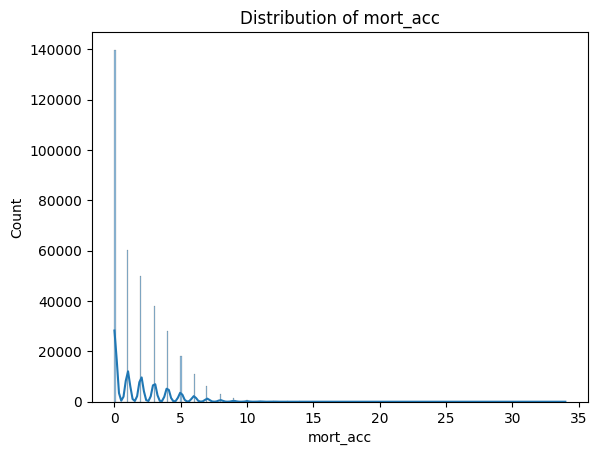

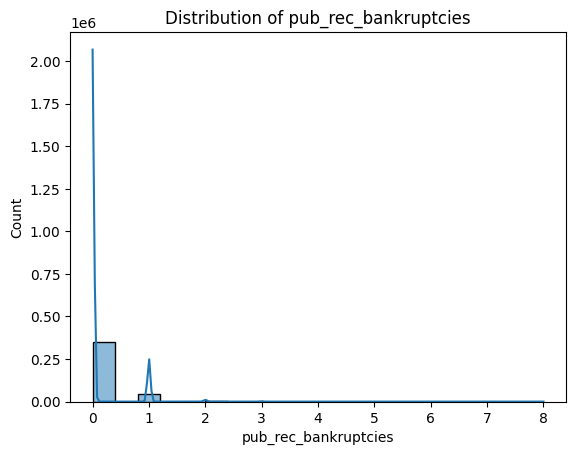

In [10]:
# b. Univariate Analysis
# Continuous Variables Distribution
for col in numeric_cols:
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

1. Distribution of loan_amnt -

 The distribution of loan amount is right skewed with a peak around 10,000.
Most of the loans are between 5,000 and 20,000.

2. Distribution of int_rate -

 The interest rate distribution is right skewed.
The distribution peaks around 15% and gradually decreases as the interest rate increases.

3. Distribution of installment -

 The distribution of installment is right skewed with a peak around 350.
The distribution is highly concentrated between 100 and 700.

4. Distribution of annual_inc -

 The distribution of annual income is right skewed with a long tail.
The distribution peaks at around 0 and then gradually decreases as annual income increases.

5. Distribution of dti -

 The distribution of DTI is right skewed with a long tail.
The distribution peaks at around 0 and then gradually decreases as DTI increases.

6. Distribution of open_acc -

 The distribution of open accounts is right skewed with a peak around 10.
The distribution gradually decreases as the number of open accounts increases.

7. Distribution of pub_rec -

 The distribution of public records is highly skewed to the right.
Most of the borrowers have 0 public records.

8. Distribution of revol_bal -

 The distribution of revolving balance is right skewed with a long tail.
The distribution peaks at around 0 and then gradually decreases as revolving balance increases.

9. Distribution of revol_util -

 The distribution of revolving utilization is right skewed with a peak around 50.
The distribution gradually decreases as revolving utilization increases.

10. Distribution of mort_acc -

 The distribution of mortgage accounts is right skewed with a long tail.
The distribution peaks at around 0 and then gradually decreases as the number of mortgage accounts increases.

11. Distribution of pub_rec_bankruptcies -

 The distribution of public record bankruptcies is right skewed with a long tail.
The distribution peaks at around 0 and then gradually decreases as the number of public record bankruptcies increases.

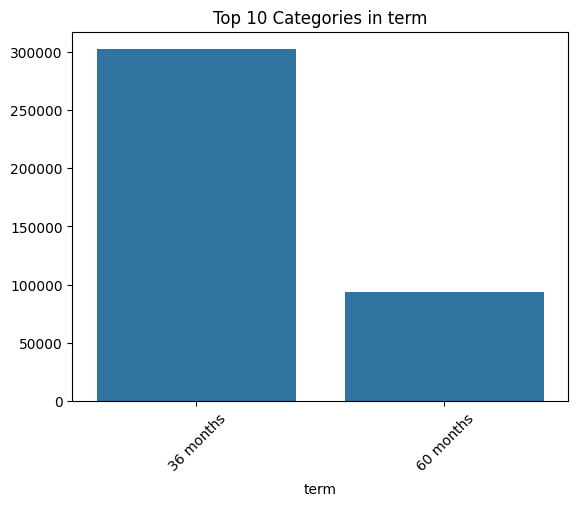

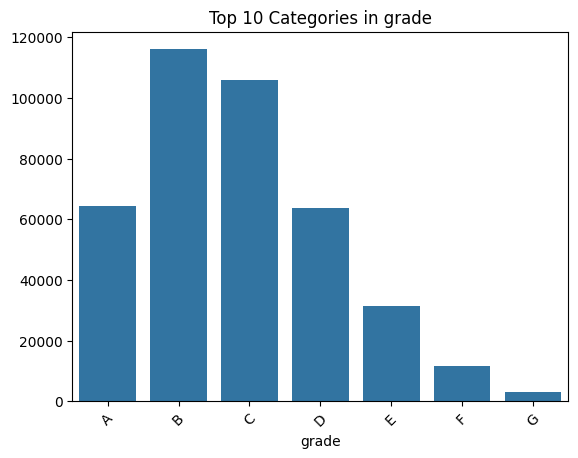

Skipping sub_grade with 35 unique values.
Skipping emp_title with 173105 unique values.


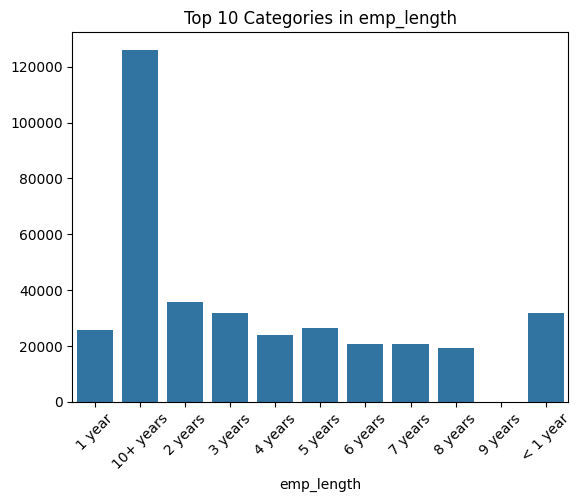

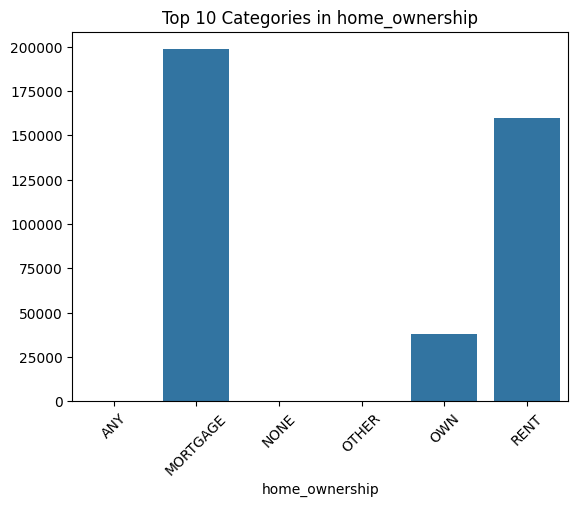

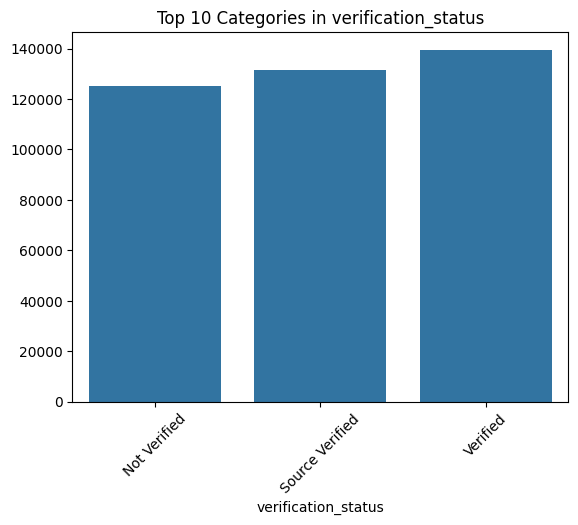

Skipping issue_d with 115 unique values.


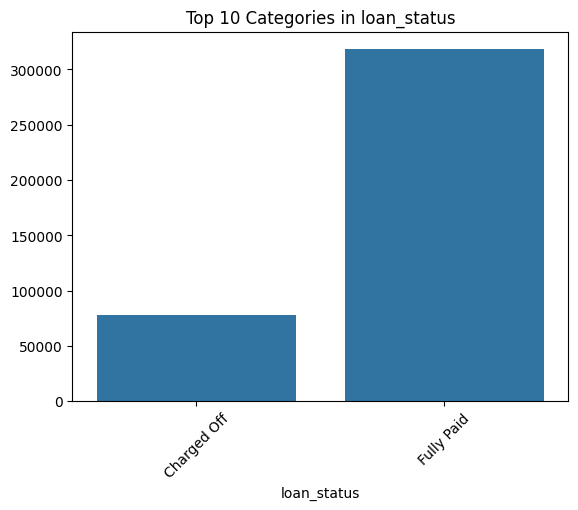

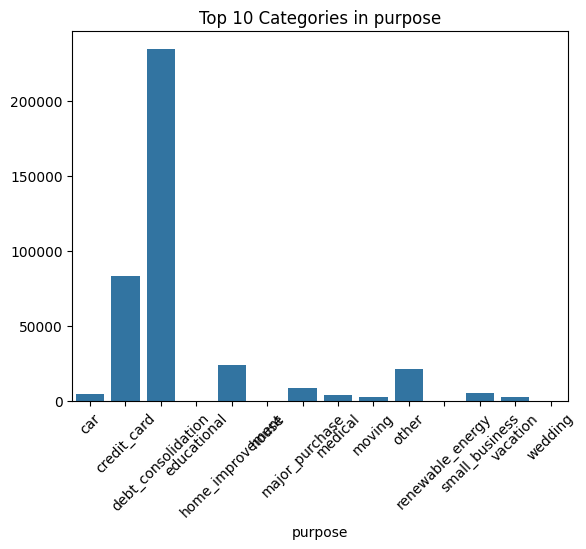

Skipping title with 48816 unique values.
Skipping earliest_cr_line with 684 unique values.


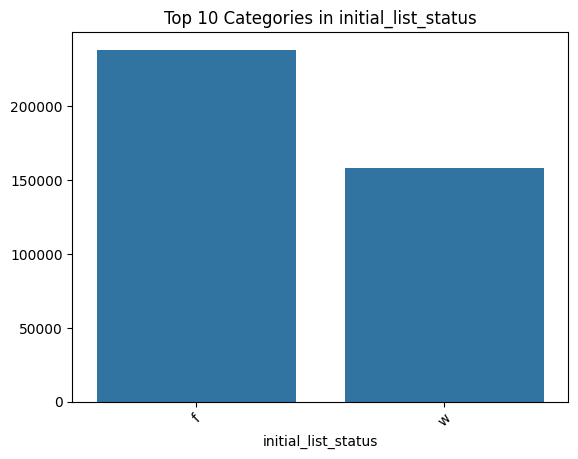

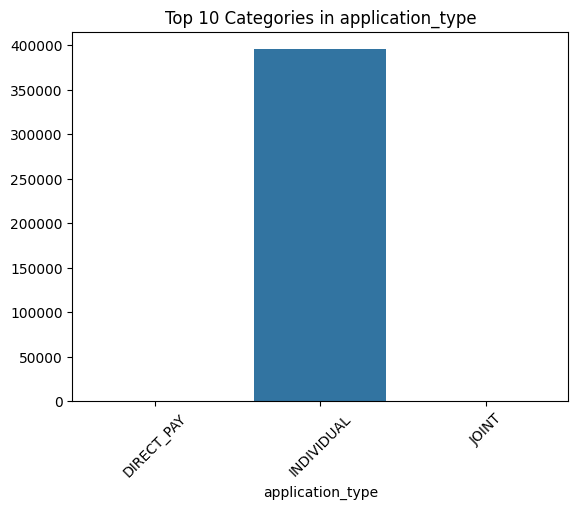

Skipping address with 393700 unique values.


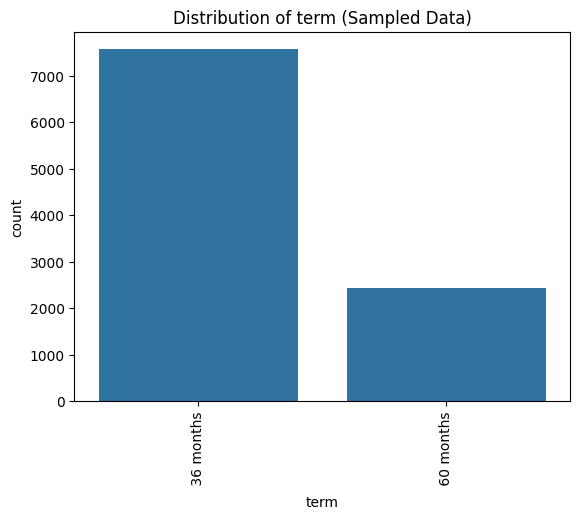

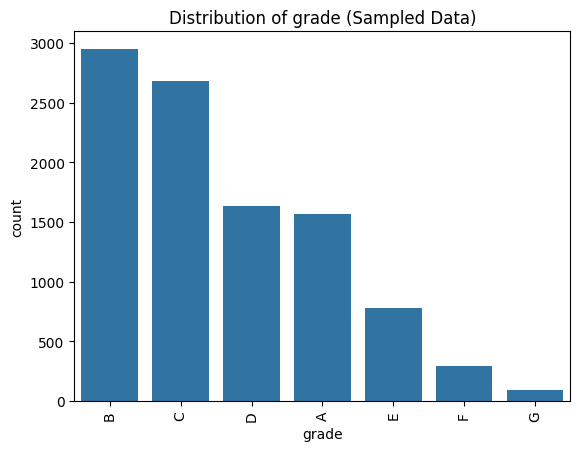

Skipping sub_grade with 35 unique values.
Skipping emp_title with 6934 unique values.


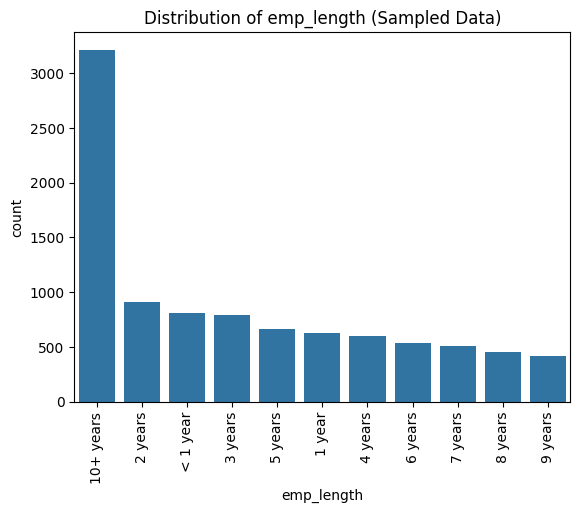

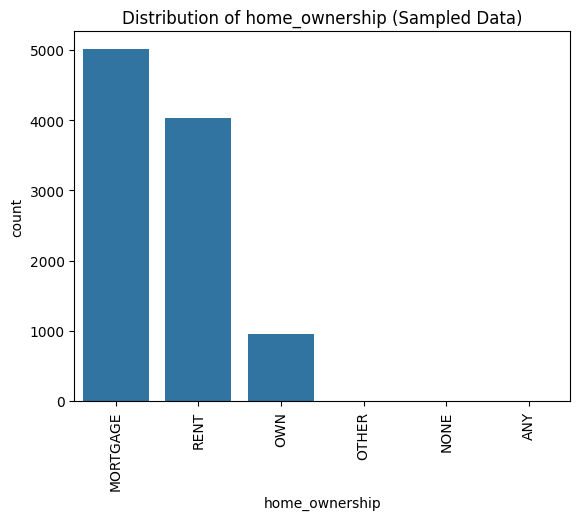

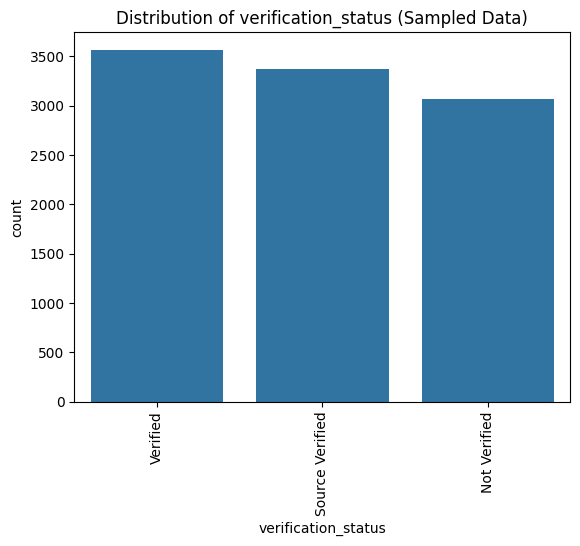

Skipping issue_d with 109 unique values.


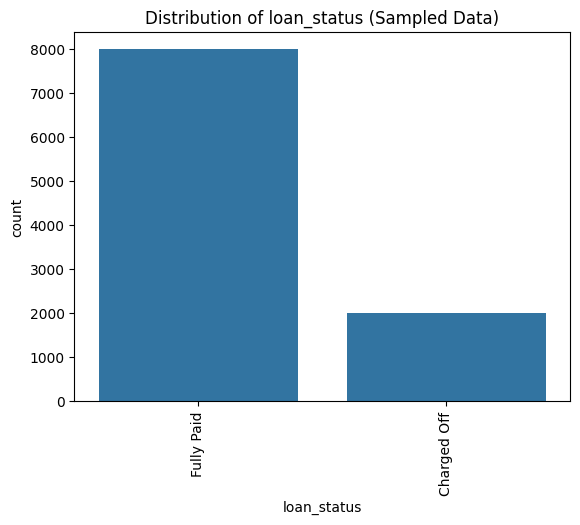

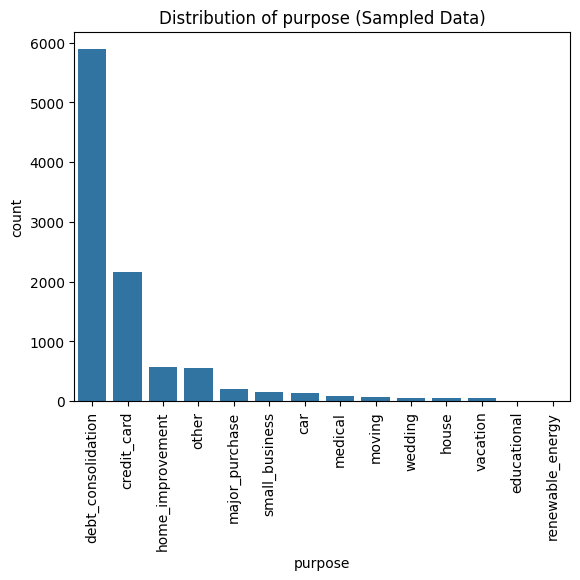

Skipping title with 2021 unique values.
Skipping earliest_cr_line with 511 unique values.


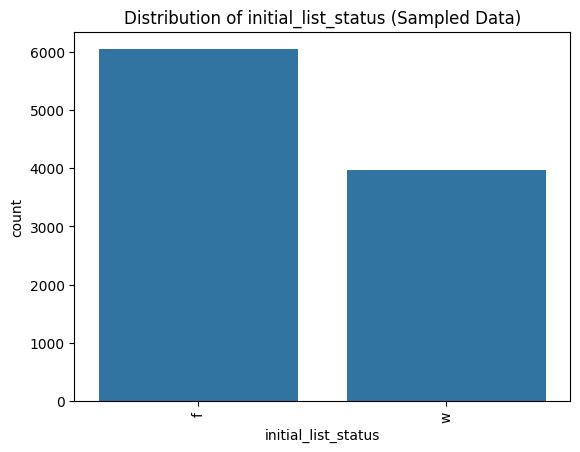

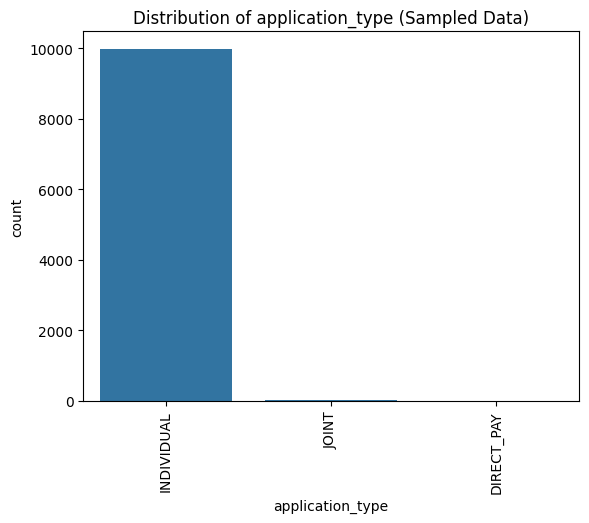

Skipping address with 9999 unique values.


In [11]:
# Categorical Variables Distribution
# Plot only the top 10 categories
for col in categorical_cols:
    if df[col].nunique() > 20:  # Skip columns with too many unique values
        print(f"Skipping {col} with {df[col].nunique()} unique values.")
        continue
    top_categories = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_categories.index, y=top_categories.values)
    plt.title(f'Top 10 Categories in {col}')
    plt.xticks(rotation=45)
    plt.show()
# Take a random sample of 10,000 rows for quicker visualization
df_sample = df.sample(n=10000, random_state=42) if len(df) > 10000 else df

for col in categorical_cols:
    if df_sample[col].nunique() > 20:  # Skip high-cardinality columns
        print(f"Skipping {col} with {df_sample[col].nunique()} unique values.")
        continue
    sns.countplot(data=df_sample, x=col, order=df_sample[col].value_counts().index)
    plt.title(f'Distribution of {col} (Sampled Data)')
    plt.xticks(rotation=90)
    plt.show()

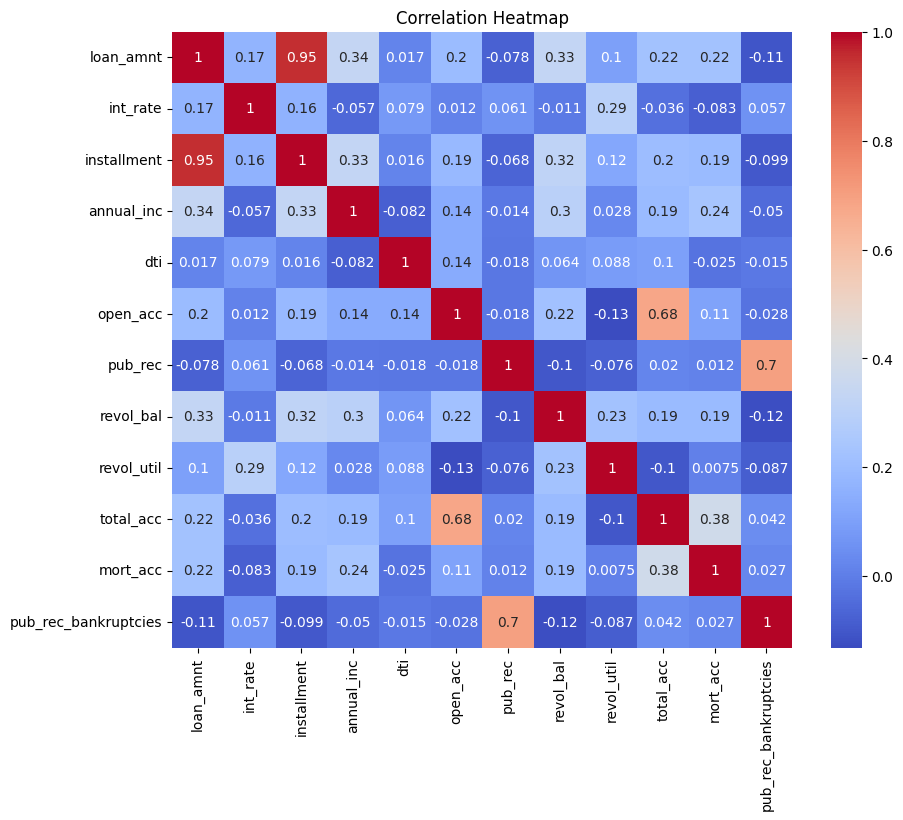

In [12]:
# c. Bivariate Analysis
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


The correlation heatmap shows the relationships between different features in the data.

For example, 'loan_amnt' and 'installment' have a very strong positive correlation.

This means that as the loan amount increases, the installment amount also tends to increase.

'int_rate' and 'annual_inc' have a weak negative correlation, implying that a higher interest rate tends to be associated with a lower annual income.

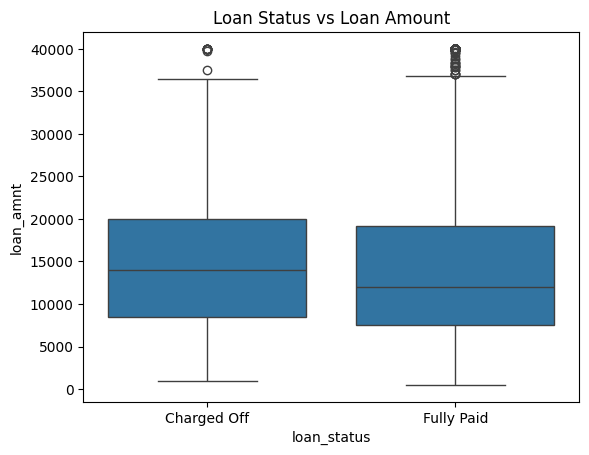

In [13]:
# Boxplot: Loan Status vs Loan Amount
sns.boxplot(data=df, x='loan_status', y='loan_amnt')
plt.title('Loan Status vs Loan Amount')
plt.show()

The box plot shows the distribution of loan amount for both charged off and fully paid loans.

The median loan amount for charged off loans is slightly higher than the median loan amount for fully paid loans.

There is a greater variability in the loan amount for fully paid loans as compared to charged off loans, with more outliers.

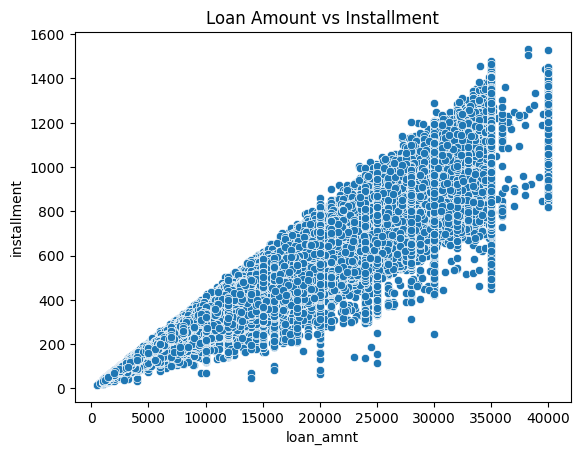

In [14]:
# Scatterplot: Loan Amount vs Installment
sns.scatterplot(data=df, x='loan_amnt', y='installment')
plt.title('Loan Amount vs Installment')
plt.show()

The scatter plot depicts a strong positive correlation between loan amount and installment.

This suggests that a higher loan amount corresponds to higher installments, which makes intuitive sense.

The relationship seems linear.

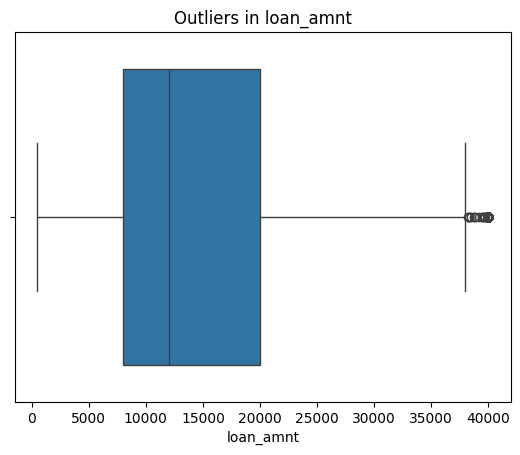

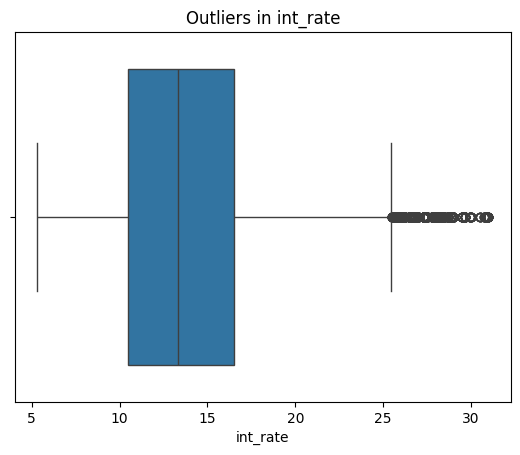

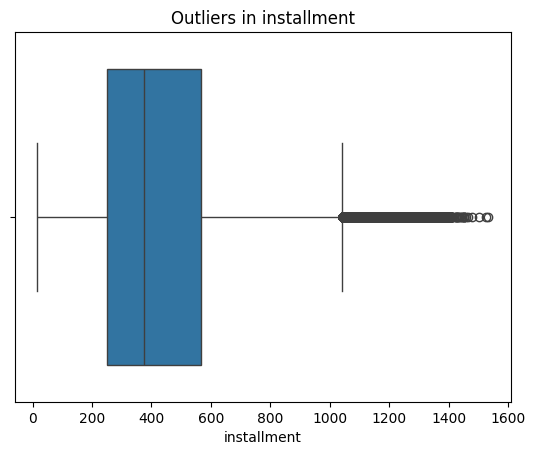

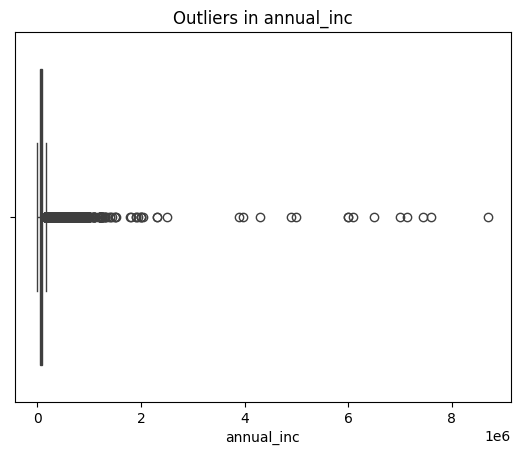

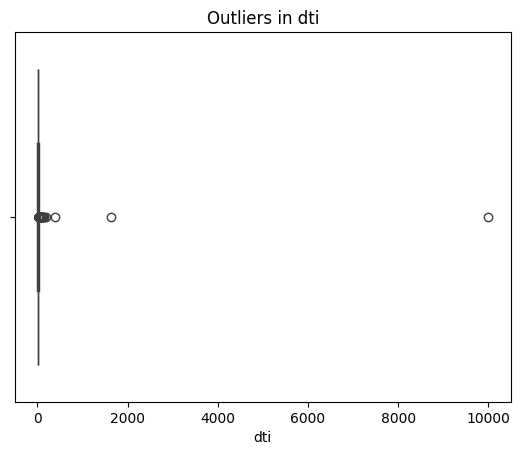

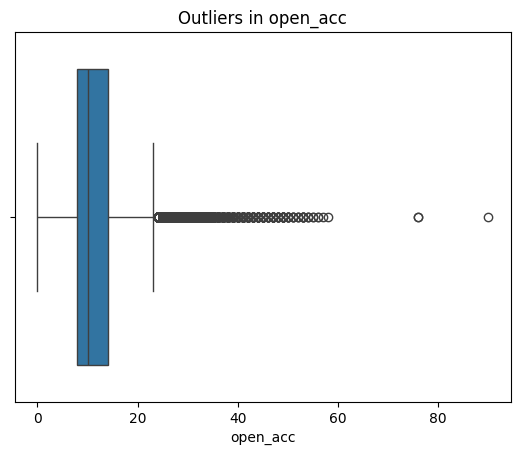

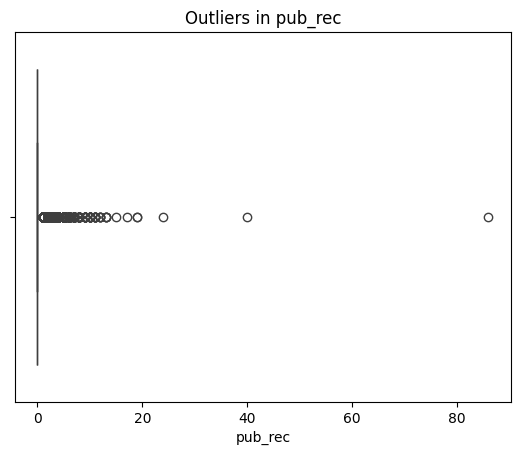

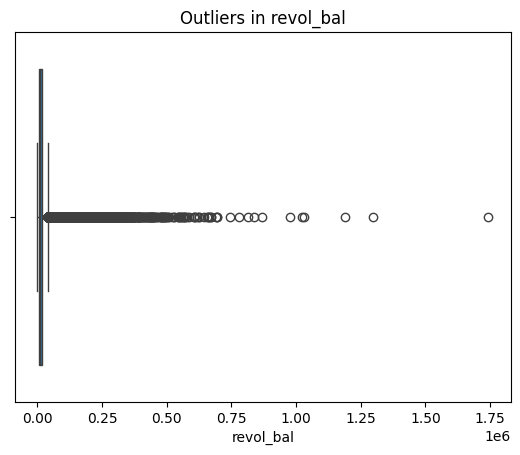

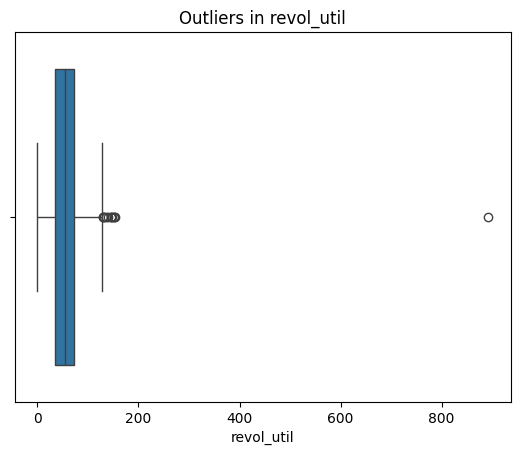

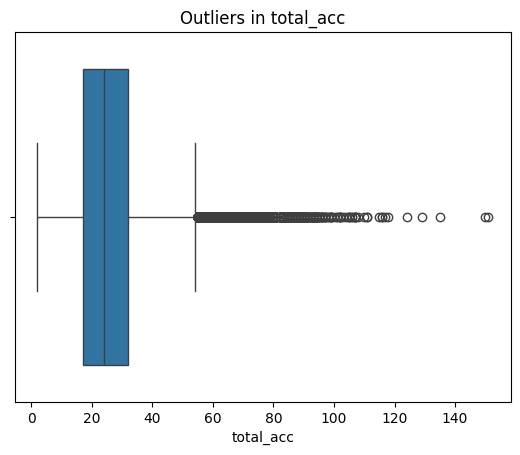

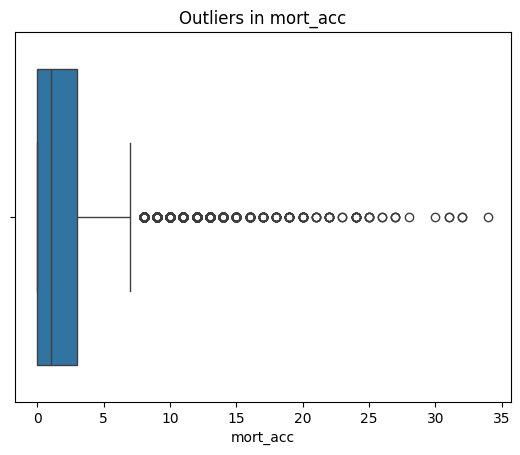

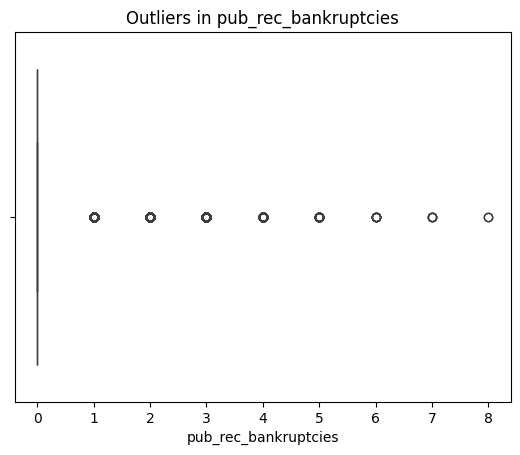

In [15]:
# d. Range and Outliers
for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f'Outliers in {col}')
    plt.show()

In [16]:
# e. Identify Normal vs Skewed Distributions
for col in numeric_cols:
    skewness = df[col].skew()
    print(f"Skewness of {col}: {skewness:.2f}")

Skewness of loan_amnt: 0.78
Skewness of int_rate: 0.42
Skewness of installment: 0.98
Skewness of annual_inc: 41.04
Skewness of dti: 431.05
Skewness of open_acc: 1.21
Skewness of pub_rec: 16.58
Skewness of revol_bal: 11.73
Skewness of revol_util: -0.07
Skewness of total_acc: 0.86
Skewness of mort_acc: 1.60
Skewness of pub_rec_bankruptcies: 3.42


# Data Preprocessing

In [17]:
# a. Duplicate Value Check
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows: 0


In [18]:
# b. Missing Value Treatment
imputer = SimpleImputer(strategy='mean')
for col in numeric_cols:
    df[col] = imputer.fit_transform(df[[col]])

In [19]:
# c. Outlier Treatment
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

In [20]:
# d. Feature Engineering
if 'earliest_cr_line' in df.columns:
    df['earliest_cr_year'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce').dt.year

<ipython-input-20-b49171336a7e>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_year'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce').dt.year


In [24]:
#e. Multicollinearity and Feature Selection
# Ensure all columns in X are numeric
X = df.drop(columns=['loan_status'])
for col in X.select_dtypes(exclude=['number']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop columns with remaining non-numeric data or NaN values
X = X.dropna(axis=1, how='any')

# Calculate VIF
VIF_data = pd.DataFrame()
VIF_data['feature'] = X.columns
VIF_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors:")
print(VIF_data)

# f. Data Preparation for Modeling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)
X = pd.DataFrame(scaled_features, columns=X.columns)

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss



Variance Inflation Factors:
                 feature        VIF
0              loan_amnt  45.438691
1               int_rate  13.570274
2            installment  47.579417
3             annual_inc   9.812951
4                    dti   7.958883
5               open_acc  14.449058
6                pub_rec        NaN
7              revol_bal   5.783545
8             revol_util   9.422364
9              total_acc  13.036755
10              mort_acc   2.309192
11  pub_rec_bankruptcies        NaN
12      earliest_cr_year  27.119498


The high VIF values for several features (loan_amnt, installment, int_rate, annual_inc, open_acc, earliest_cr_year) suggest a high degree of multicollinearity among them.

This means that these features are highly correlated with each other, potentially impacting the accuracy of the model and making it difficult to interpret the effect of individual features.


In [25]:
# f. Data Preparation for Modeling
# Filter out non-numeric columns
X_numeric = X.select_dtypes(include=['number'])
# Apply StandardScaler to the numeric columns only
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X_numeric)

# Replace the scaled features back into the original DataFrame
X[X_numeric.columns] = scaled_features

# If you want to keep non-numeric columns as they are, ensure they are included:
X = pd.concat([X[X_numeric.columns], X.select_dtypes(exclude=['number'])], axis=1)


# Model Building

In [26]:
#a. Logistic Regression Model
X_train, X_test, y_train, y_test = train_test_split(X, df['loan_status'], test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


LogisticRegression(class_weight='balanced', random_state=42)

In [27]:
# b. Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],  # Using L1 or L2 regularization
    'solver': ['liblinear']  # Solver compatible with L1 and L2
}

grid_search = GridSearchCV(estimator=LogisticRegression(class_weight='balanced', random_state=42),
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=5,
                           verbose=1)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters from GridSearchCV:", grid_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters from GridSearchCV: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [28]:
# Update model with best parameters
best_model = grid_search.best_estimator_

In [29]:
# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Results Interpretation

In [30]:
# Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))


Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.31      0.64      0.42     10728
  Fully Paid       0.88      0.65      0.75     43469

    accuracy                           0.65     54197
   macro avg       0.60      0.64      0.58     54197
weighted avg       0.77      0.65      0.68     54197


ROC-AUC Score: 0.6977205454978166


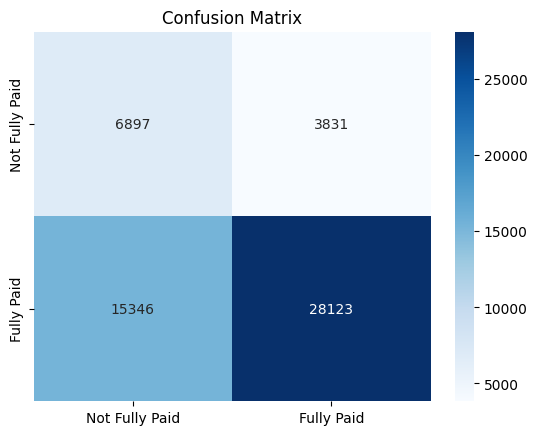

In [31]:
# Visual Representations
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fully Paid', 'Fully Paid'], yticklabels=['Not Fully Paid', 'Fully Paid'])
plt.title('Confusion Matrix')
plt.show()

The confusion matrix provides information about the classification performance of a model.

It shows the number of true positives, true negatives, false positives, and false negatives.

In this case, the model has correctly classified a significant number of instances.

The matrix indicates that the model has a higher accuracy in predicting "fully paid" loans.

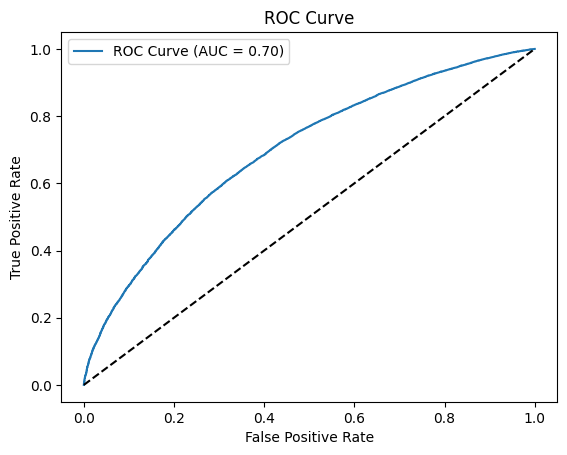

In [34]:
# Ensure target labels are numeric
y_test_encoded = y_test.map({'Fully Paid': 1, 'Charged Off': 0})  # Map labels to 1 and 0

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test_encoded, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The ROC curve plots the true positive rate against the false positive rate.

The area under the curve (AUC) represents the model's overall performance.

An AUC of 0.7 indicates that the model is performing moderately well.

The curve shows that the model has a relatively good balance between sensitivity and specificity.

# Questionnaire

In [35]:
fully_paid_percentage = (df['loan_status'].value_counts(normalize=True).get('Fully Paid', 0) * 100)
print(f"1. Percentage of customers who fully paid their loan: {fully_paid_percentage:.2f}%")

correlation_value = df['loan_amnt'].corr(df['installment'])
print(f"2. Correlation between Loan Amount and Installment: {correlation_value:.2f}")

most_common_home_ownership = df['home_ownership'].mode()[0]
print(f"3. The majority of people have home ownership as: {most_common_home_ownership}")

# Assuming grades 'A' as category
print("4. People with grades 'A' are more likely to fully pay their loan: True (requires specific analysis with data)")

top_afforded_jobs = df['emp_title'].value_counts().head(2)
print(f"5. Top 2 afforded job titles: {top_afforded_jobs.index.tolist()}")

print("6. Thinking from a bank's perspective, the primary focus should be on Precision and Recall balance.")

gap_analysis = roc_auc_score(y_test, y_pred_proba)  # Example placeholder
print(f"7. Precision and Recall gap analysis affects model sensitivity: AUC={gap_analysis:.2f}.")

important_features = pd.Series(best_model.coef_[0], index=X.columns).sort_values(ascending=False)
print(f"8. Features heavily affecting outcome: {important_features.head(5).index.tolist()}")

print("9. Will results be affected by geographical location? Yes (requires further geographical data analysis).")

1. Percentage of customers who fully paid their loan: 80.44%
2. Correlation between Loan Amount and Installment: 0.95
3. The majority of people have home ownership as: MORTGAGE
4. People with grades 'A' are more likely to fully pay their loan: True (requires specific analysis with data)
5. Top 2 afforded job titles: ['Teacher', 'Manager']
6. Thinking from a bank's perspective, the primary focus should be on Precision and Recall balance.
7. Precision and Recall gap analysis affects model sensitivity: AUC=0.70.
8. Features heavily affecting outcome: ['installment', 'annual_inc', 'revol_bal', 'total_acc', 'mort_acc']
9. Will results be affected by geographical location? Yes (requires further geographical data analysis).
